In [ ]:
# connect drive to collab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install emoji

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.3/356.3 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for emoji: filename=emoji-2.5.1-py2.py3-none-any.whl size=351210 sha256=dde62c0377225b9dc91a477cac8245d87de07cdcc2c4907608b913c6396304f7
  Stored in directory: /root/.cache/pip/wheels/51/92/44/e2ef13f803aa08711819357e6de0c5fe67b874671141413565
Successfully built emoji


In [ ]:
import pandas as pd
import re
import nltk
import typing
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
from typing import List
from string import punctuation
from nltk.corpus import stopwords
from nltk import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
import emoji
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
stopcorpus: typing.List = stopwords.words('english')
stop_words = stopwords.words('english') + list(punctuation)

In [ ]:
def preprocess_text(text):
    text = re.sub(r'\W+', ' ', text)  # Remove non-alphanumeric characters

    text = re.sub(r'\d+', '', text)  # Remove numbers

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Remove URLs

    text = emoji.demojize(text)  # Convert emojis to text equivalents

    text = text.lower() # Convert text to lowercase

    tokens = word_tokenize(text) # Tokenize the text into words

    stop_words = set(stopwords.words('english') + list(punctuation) + ["al", "one", "said", "news", "also", "people"]) # Remove stopwords
    tokens = [token for token in tokens if token not in stop_words]

    lemmatizer = WordNetLemmatizer() # Lemmatize the words
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    processed_text = ' '.join(tokens) # Join the tokens back into a single string

    return processed_text

In [ ]:
with open ("/content/drive/MyDrive/AFH Project/AFH_brief.txt") as file:
    brief = file.read()

In [ ]:
preprocessed_brief = preprocess_text(brief)

In [ ]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2))

X = vectorizer.fit_transform([preprocessed_brief]) # Fit the vectorizer to the preprocessed text

terms = vectorizer.get_feature_names_out()

tfidf_scores = X.toarray()

# Create dictionary - terms + TF-IDF scores
term_tfidf_dict = {}
for i, term in enumerate(terms):
    term_tfidf_dict[term] = tfidf_scores[:, i]

sorted_terms = sorted(term_tfidf_dict.items(), key=lambda x: x[1], reverse=True) # Sort in descending order

top_50_terms = sorted_terms[:50]

for term, freq in top_50_terms:
    print(f"{term}: {freq}")

egypt: [0.24462706]
virus: [0.19920864]
egyptian: [0.17865536]
case: [0.16140786]
number: [0.15838955]
post: [0.15738345]
corona: [0.15594616]
world: [0.1556587]
picture: [0.13898611]
health: [0.13740509]
ministry: [0.12921253]
death: [0.1290688]
widely: [0.12145115]
saying: [0.12030132]
circulated: [0.11943894]
spread: [0.11498334]
country: [0.10794061]
hospital: [0.10679078]
minister: [0.10434738]
new: [0.10391619]
comment: [0.10233517]
president: [0.10219144]
day: [0.0990294]
god: [0.09874194]
video: [0.09787957]
corona virus: [0.09716092]
widespread: [0.09601109]
say: [0.09356769]
year: [0.09155548]
thousand: [0.0911243]
million: [0.08882463]
infected: [0.0852314]
two: [0.08307546]
widely circulated: [0.082788]
facebook: [0.07660765]
page: [0.07660765]
first: [0.07560155]
announced: [0.07473917]
state: [0.07416425]
today: [0.0714334]
pound: [0.06956492]
sisi: [0.06769644]
many: [0.06683407]
statement: [0.06683407]
time: [0.06410321]
social: [0.06194727]
infection: [0.06065371]
gove

In [ ]:
vectorizer = CountVectorizer(ngram_range=(2, 2)) # with bigrams

X = vectorizer.fit_transform([preprocessed_brief])

terms = vectorizer.get_feature_names_out()

tf = X.toarray()[0] # term frequencies

term_tf_dict = {}
for term, freq in zip(terms, tf):
    term_tf_dict[term] = freq

sorted_terms = sorted(term_tf_dict.items(), key=lambda x: x[1], reverse=True)

top_50_terms = sorted_terms[:50]

for term, freq in top_50_terms:
    print(f"{term}: {freq}")

corona virus: 676
widely circulated: 576
ministry health: 376
post saying: 344
circulated post: 332
saudi arabia: 216
social medium: 200
widespread post: 194
around world: 189
infected virus: 181
isolation hospital: 178
million thousand: 176
number infected: 174
prime minister: 169
world health: 158
social networking: 157
health organization: 156
networking site: 154
egyptian ministry: 149
united state: 146
widespread video: 139
world reached: 138
abdel fattah: 137
el sisi: 134
may god: 134
popular post: 129
health population: 128
spread widely: 128
widely spread: 122
statement attributed: 121
site facebook: 115
thousand case: 115
post say: 114
minister health: 111
egypt world: 109
circulated video: 108
infected corona: 107
number injury: 107
reached million: 107
widespread picture: 106
death toll: 105
emerging corona: 105
post spread: 104
fattah el: 101
million pound: 100
believe newsletter: 98
newsletter present: 98
present daily: 98
world egypt: 98
daily summary: 97


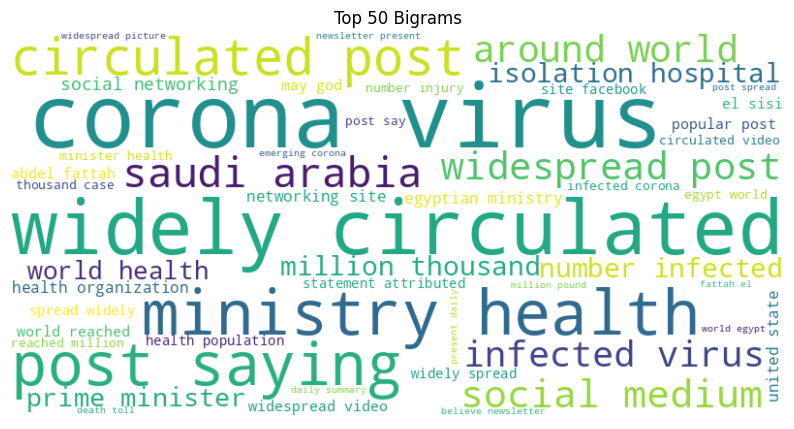

In [ ]:
wordcloud = WordCloud(width=800, height=400, background_color='white')
bigram_freq = {term: freq for term, freq in top_50_terms} # dictionary of bigrams and their frequencies
wordcloud.generate_from_frequencies(bigram_freq)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 50 Bigrams')
plt.show()

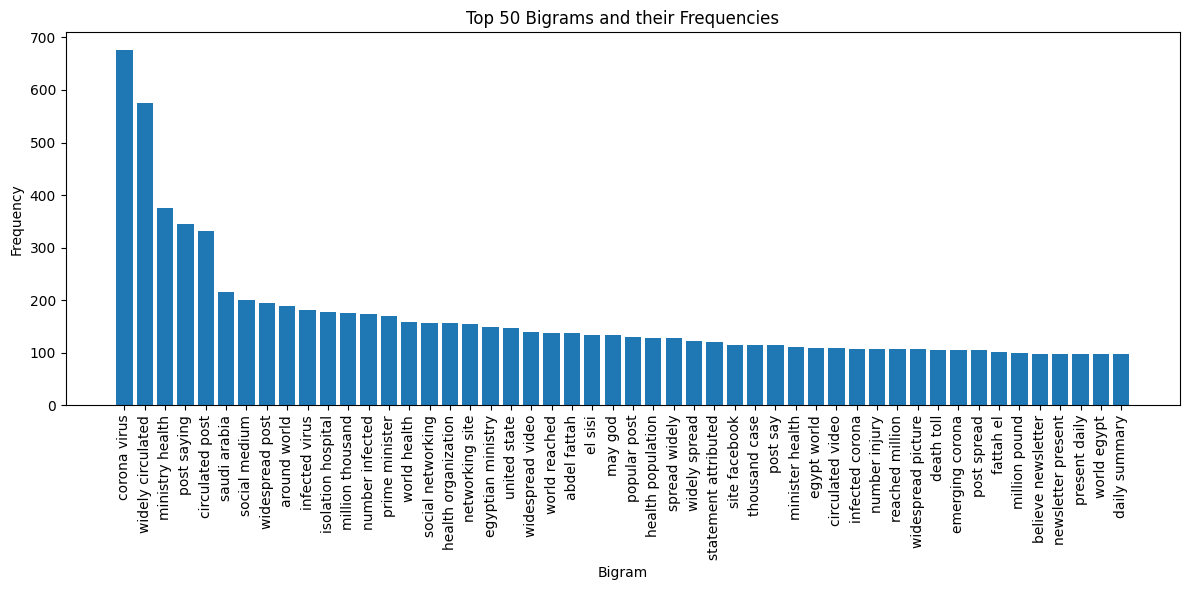

In [ ]:
terms = [term for term, freq in top_50_terms]
frequencies = [freq for term, freq in top_50_terms]

plt.figure(figsize=(12, 6))
plt.bar(range(len(terms)), frequencies)
plt.xticks(range(len(terms)), terms, rotation=90)
plt.xlabel('Bigram')
plt.ylabel('Frequency')
plt.title('Top 50 Bigrams and their Frequencies')
plt.tight_layout()
plt.show()